# **Домашнее задание 3**

В этом домашнем задании вам предстоит справиться с теоретическими и практическими упражнениями.

**Все результаты должны быть прокомментированы.**

Максимальная сумма баллов за все задания - 10 баллов.

## **Часть 1 (2 балла)**

In [13]:
import math
import numpy as np

На лекции и семинаре вы изучали такие понятия, как энтропия и информационный выигрыш. Сейчас мы попрактикуемся в их вычислении.

Напомним, что **энтропия Шеннона** вычисляется следующим образом по N возможному числу состояний:

$$\large S = - \sum_{i=1}^N p_i log_2 p_i$$

где $p_i$ - вероятность найти систему в i-ом состоянии.

Рассмотрим пример. Пусть дана система (датасет), в которой определены два состояния (вероятности). Первое $\large p_1=\frac{3}{7}$ и второе $\large p_2=\frac{4}{7}$. Тогда энтропия вычисляется так:

$\large S_0=−\frac{3}{7} * log_2 \frac{3}{7} - \frac{4}{7} * log_2 \frac{4}{7} ≈ 0.9852$

Теперь рассмотрим случай, когда систему (датасет) поделили относительно некоторого признака. На левую часть и на правую. Чему теперь равна энтропия каждой из частей? И чему будет равен информационный выигрыш при таком делении?

Энтропия левой части равна: $\normalsize S_1=−\frac{1}{4} * log_2 \frac{1}{4} - \frac{3}{4} * log_2 \frac{3}{4} ≈ 0.8113$.

Энтропия правой части равна: $\normalsize S_2=−\frac{2}{3} * log_2 \frac{2}{3} - \frac{1}{3} * log_2 \frac{1}{3} ≈ 0.9183$.

Как вы можете видеть, значение энтропии стало меньше в двух группах. Особенно в левой группе. Посколько энтропия является мерой хаоса (или неопределённости) в системе, то мы говорим, что информационный выигрыш характеризуется уменьшением энтропии.

Информационный выигрыш (Information Gain, IG) для разделения на основе признака Q выглядит следующим образом:

$$\large IG(Q)=S_0 - \sum_{i=1}^q\frac{N_i}{N} S_i$$

где $q$ - число групп после деления, $N_i$ - количество объектов в выборке, в которой признак $Q$ равен i-ому значению.

**Информационный выигрыш = сколько энтропии мы удалили**, поэтому для нашего примера:

$$\normalsize IG=0.985 − (\frac{3}{7} * 0.9183 + \frac{4}{7} * 0.8113) ≈ 0.985 - 0.857 = 0.128 $$

Теперь напишем функции для вычисления энтропии и информационного выигрыша.

Рассмотрим следующий простой пример: у нас есть 9 синих и 11 жёлтых мячей. Пусть мяч будет иметь метку **1**, если он синий, и **0** в противном случае.

In [1]:
balls = [1 for i in range(9)] + [0 for i in range(11)]
balls

[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

<img src = 'https://habrastorage.org/webt/mu/vl/mt/muvlmtd2njeqf18trbldenpqvnm.png'>

Затем разделим мячи на две группы по некоторому признаку:

<img src='https://habrastorage.org/webt/bd/aq/5w/bdaq5wi3c4feezaexponvin8wmo.png'>

In [3]:
# две группы

balls_left  = [1 for i in range(8)] + [0 for i in range(5)] # 8 синих и 5 жёлтых
balls_right = [1 for i in range(1)] + [0 for i in range(6)] # 1 синий и 6 жёлтых
balls_left, balls_right

([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0], [1, 0, 0, 0, 0, 0, 0])

In [5]:
list(set(balls)).count(0)

1

### **Задание 1 (0.5 балла)**

Напишите функцию, вычисляющую энтропию по Шеннону. И примените её для для следующих наборов данных.

In [8]:
def entropy(list_):
    objects = list(set(list_))
    p=[]
    e=0
    for i in objects:
        p.append(list_.count(i)/len(list_))
    for i in p:
        e+=i*np.log2(i)
    return -e
        

Проверка:

In [15]:
print(entropy(balls)) # 9 синих и 11 жёлтых
print(entropy(balls_left)) # 8 синих и 5 жёлтых
print(entropy(balls_right)) # 1 синий и 6 жёлтых

0.9927744539878083
0.9612366047228759
0.5916727785823275


### **Задание 2 (0.5 балла)**

Чему равна энтропия бросания монетки (без учёта ребра и с равными вероятностями для сторон монетки)?

In [18]:
e=-(0.5*np.log2(0.5)+0.5*np.log2(0.5))
print(e)

1.0


### **Задание 3 (0.5 балла)**

Чему равна энтропия игральной кости (мы рассматриваем игральную кость, как систему с 6 равновероятными состояниями)?

In [21]:
e=-((1/6*np.log2(1/6))*6)
print(e)

2.584962500721156


In [23]:
entropy(balls)

0.9927744539878083

### **Задание 4 (0.5 балла)**

Напишите функцию, которая вычисляет информационный выигрыш при делении исходных данных на **balls_left** and **balls_right** ?

In [26]:
# вычисление информационного выигрыша

def information_gain(full_data, left, right):
    m= entropy(full_data)
    l= entropy(left)
    r=entropy(right)
    IO=m-len(left)/len(full_data)*l-len(right)/len(full_data)*r
    return IO
    

Проверка:

In [29]:
print(round(information_gain(balls, balls_left, balls_right), 3))

0.161


## **Часть 2 (7 баллов)**

### **Данные**

Мы будем обучать модели машинного обучения, ставить эксперименты, подбирать гиперпараметры, сравнивать модели. Вам предлагается решить задачу бинарной классификации, а именно построить алгоритм, определяющий превысит ли средний заработок человека порог $50k. Каждый объект выборки — человек, для которого известны следующие признаки:

 - age
 - workclass
 - fnlwgt
 - education
 - education-num
 - marital-status
 - occupation
 - relationship
 - race
 - sex
 - capital-gain
 - capital-loss
 - hours-per-week

Более подробно про признаки можно почитать [здесь](http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.names). Целевой признак записан в переменной *>50K,<=50K*.

### **Метрика качества**

В задании мы будем оценивать качество моделей с помощью метрики AUC-ROC.

### **Подбор гиперпараметров модели**

В задачах машинного обучения следует различать параметры модели и гиперпараметры (структурные параметры). Обычно параметры модели настраиваются в ходе обучения (например, веса в линейной модели или структура решающего дерева), в то время как гиперпараметры задаются заранее (например, регуляризация в линейной модели или максимальная глубина решающего дерева). Каждая модель обычно имеет множество гиперпараметров, и нет универсальных наборов гиперпараметров, оптимально работающих во всех задачах, для каждой задачи нужно подбирать свой набор.

Для оптимизации гиперпараметров модели часто используют _перебор по сетке (grid search)_: для каждого гиперпараметра выбирается несколько значений, перебираются все комбинации значений и выбирается комбинация, на которой модель показывает лучшее качество (с точки зрения метрики, которая оптимизируется). Однако в этом случае нужно грамотно оценивать построенную модель, а именно делать разбиение на обучающую и тестовую выборку. Есть несколько схем, как это можно реализовать:

 - Разбить имеющуюся выборку на обучающую и тестовую. В этом случае сравнение большого числа моделей при переборе параметров приводит к ситуации, когда лучшая на тестовой подвыборке модель не сохраняет свои качества на новых данных. Можно сказать, что происходит _переобучение_ на тестовую выборку.
 - Для устранения описанной выше проблемы, можно разбить данные на 3 непересекающихся подвыборки: обучение (`train`), валидация (`validation`) и контроль (`test`). Валидационную подвыборку используют для сравнения моделей, а `test` — для окончательной оценки качества и сравнения семейств моделей с подобранными параметрами.
 - Другой способ сравнения моделей — [кросс-валидация](http://en.wikipedia.org/wiki/Cross-validation_(statistics)). Существуют различные схемы кросс-валидации:
   - Leave-One-Out;
   - K-Fold;
   - Многократное случайное разбиение выборки.

Кросс-валидация вычислительно затратна, особенно если вы делаете перебор по сетке с очень большим числом комбинации. С учетом конечности времени на выполнение задания, возникает ряд компромиссов:
  - сетку можно делать более разреженной, перебирая меньше значений каждого параметра; однако, надо не забывать, что в таком случае можно пропустить хорошую комбинацию параметров;
  - кросс-валидацию можно делать с меньшим числом разбиений или фолдов, но в таком случае оценка качества кросс-валидации становится более шумной и увеличивается риск выбрать неоптимальный набор параметров из-за случайности разбиения;
  - параметры можно оптимизировать последовательно (жадно) — один за другим, а не перебирать все комбинации; такая стратегия не всегда приводит к оптимальному набору;
  - перебирать не все комбинации параметров, а небольшое число случайно выбранных.

### **Предобработка**

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification

from sklearn.model_selection import cross_val_score

from sklearn.datasets import load_iris, load_breast_cancer, load_wine

import time

Загрузим набор данных `data.adult.csv`. Чтобы лучше понимать, с чем вы работаете / корректно ли вы загрузили данные, можно вывести несколько первых строк на экран.

In [34]:
df = pd.read_csv('data.adult.csv')

df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,">50K,<=50K"
0,34,Local-gov,284843,HS-grad,9,Never-married,Farming-fishing,Not-in-family,Black,Male,594,0,60,<=50K
1,40,Private,190290,Some-college,10,Divorced,Sales,Not-in-family,White,Male,0,0,40,<=50K
2,36,Local-gov,177858,Bachelors,13,Married-civ-spouse,Prof-specialty,Own-child,White,Male,0,0,40,<=50K
3,22,Private,184756,Some-college,10,Never-married,Sales,Own-child,White,Female,0,0,30,<=50K
4,47,Private,149700,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,15024,0,40,>50K
5,18,Private,446771,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0,0,25,<=50K
6,31,Federal-gov,108464,Assoc-acdm,12,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,<=50K
7,18,?,423460,11th,7,Never-married,?,Own-child,White,Male,0,0,36,<=50K
8,25,Private,110138,HS-grad,9,Never-married,Other-service,Not-in-family,White,Male,0,0,40,<=50K
9,53,Federal-gov,167410,Bachelors,13,Divorced,Tech-support,Not-in-family,Amer-Indian-Eskimo,Male,0,0,40,<=50K


Посмотрим на типы колонок.

In [37]:
df.dtypes

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
>50K,<=50K        object
dtype: object

Иногда в данных встречаются пропуски. Как задаются пропуски обычно либо прописывается в описании к данным, либо просто на месте пропуска после чтения данных оказывается значение numpy.nan. Более подробно о работе с пропусками в Pandas можно прочитать например [здесь](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html).

В данном датасете пропущенные значения обозначены как "?".

#### **Задание 5 (0.5 балла)**

Найдите все признаки, имеющие пропущенные значения. Удалите из выборки все объекты с пропусками.

In [41]:
df[df=='?'].count()

age                 0
workclass         929
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        933
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
>50K,<=50K          0
dtype: int64

In [43]:
df = df.replace("?", np.nan)

In [45]:
df=df.dropna()

#### **Задание 6 (0.5 балла)**

Обычно после загрузки датасета всегда необходима его некоторая предобработка. В данном случае она будет заключаться в следующем:

 - выделите целевую переменную в отдельную переменную, удалите ее из датасета и преобразуйте к бинарному формату.
 - обратите внимание, что не все признаки являются вещественными; в начале мы будем работать только с вещественными признаками, выделите их отдельно.

In [48]:
Y = df['>50K,<=50K'].apply(lambda x: 1 if x == '>50K' else 0)

In [50]:
df.drop('>50K,<=50K', axis=1, inplace=True)

In [52]:
X=df.select_dtypes(include=['int'])

In [54]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 15347 entries, 0 to 16279
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             15347 non-null  int64
 1   fnlwgt          15347 non-null  int64
 2   education-num   15347 non-null  int64
 3   capital-gain    15347 non-null  int64
 4   capital-loss    15347 non-null  int64
 5   hours-per-week  15347 non-null  int64
dtypes: int64(6)
memory usage: 839.3 KB


### **Обучение классификаторов на вещественных признаках**

В данном разделе необходимо будет работать только с вещественными признаками и целевой переменной.

В начале посмотрим, как работает подбор параметров по сетке, и как влияет на качество разбиение выборки. Сейчас будем рассматривать 5 следующих алгоритмов:
 - [kNN](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html);
 - [DecisonTree](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier);
 - [SGD Linear Classifier](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html);
 - [RandomForest](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html);
 - [GradientBoosting](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html).

Для начала у первых трёх алгоритмов выберем один гиперпараметр, который будем оптимизировать:
 - kNN — число соседей (`n_neighbors`);
 - DecisonTree — глубина дерева (`max_depth`);
 - SGD Linear Classifier — оптимизируемая функция (`loss`).

Остальные параметры оставляйте в значениях по умолчанию. Для подбора гиперпараметров воспользуйтесь перебором по сетке, который реализован в классе [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html). В качестве схемы кросс-валидации используйте 5-fold cv, которую можно задать с помощью класса [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html).

#### **Задание 7 (1 балл)**

Для каждого из первых трех алгоритмов подберите оптимальные значения указанных гиперпараметров. Для каждого из этих алгоритмов постройте график среднего качества по кросс-валидации при заданном значении гиперпараметра, на котором также отобразите доверительный интервал [m-std, m+std], где m - среднее, std - стандартное отклонение.

**Desicion Tree**

In [56]:
cr_val=KFold(n_splits=5,shuffle=True,random_state=1)

In [60]:
gs = GridSearchCV(DecisionTreeClassifier(random_state=1),
                  param_grid={ 'max_depth': list(range(1, 21))
                  },
                  cv=cr_val,
                  scoring='roc_auc')

gs.fit(X, Y)
print(gs.best_params_,gs.best_score_)

{'max_depth': 7} 0.8389624442687922


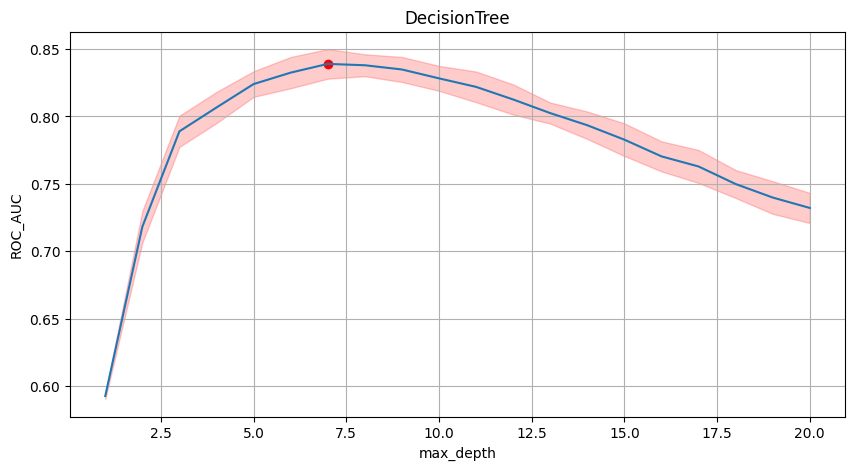

In [61]:
means=np.array(gs.cv_results_['mean_test_score'])
std=np.array(gs.cv_results_['std_test_score'])
param=np.array(gs.cv_results_['param_max_depth'],dtype=int)
plt.figure(figsize=(10,5))
plt.plot(param, means)
plt.xlabel("max_depth")
plt.ylabel("ROC_AUC")
plt.title("DecisionTree")
plt.grid()
plt.fill_between(param, means-std, means+std, alpha=0.2,color='red')
plt.scatter(7,0.8389624442687922,color='red')
plt.show()

Видим, что качество модели активно растет с 1 до 7, но затем постепенно начинает убывать из-за переобучения. Из трех моделей показывает максимум Roc-Auc и наименьший разброс.

**SGD**

In [67]:
gs1=GridSearchCV(SGDClassifier(random_state=1),
                  param_grid={ 'loss': ['hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive']
                  },
                  cv=cr_val,
                  scoring='roc_auc')
gs1.fit(X, Y)
print(gs1.best_params_,
gs1.best_score_)#видим, что классификатор не сошелся, что говорит об необходимости задать порог останова или увеличить число итераций, а иначе подобранное значение вовсе не оптимально

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/line

{'loss': 'log_loss'} 0.6153981526693891


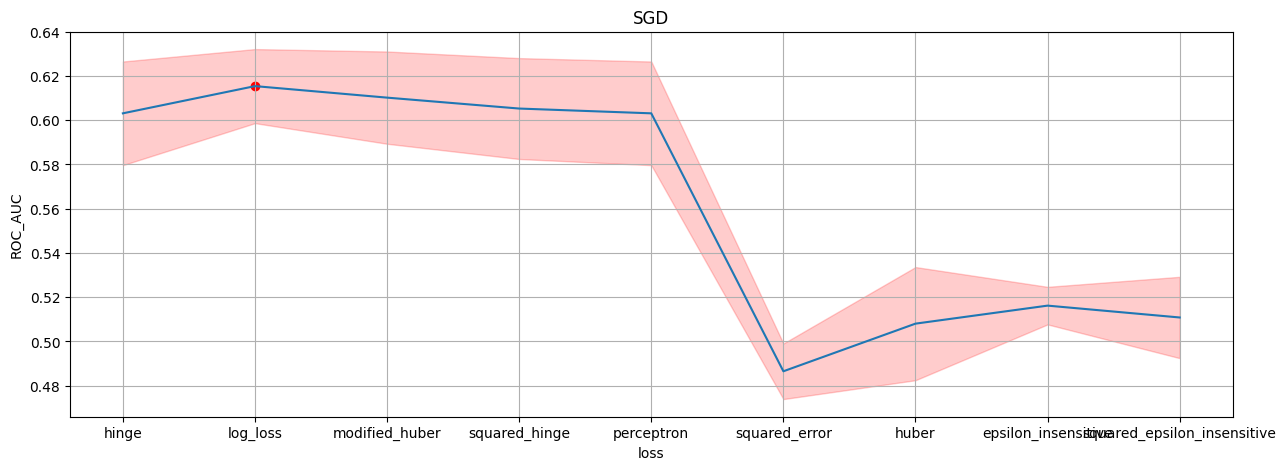

In [69]:
means1=np.array(gs1.cv_results_['mean_test_score'])
std1=np.array(gs1.cv_results_['std_test_score'])
param1=np.array(gs1.cv_results_['param_loss'])
plt.figure(figsize=(15,5))
plt.plot(param1, means1)
plt.xlabel("loss")
plt.ylabel("ROC_AUC")
plt.title("SGD")
plt.grid()
plt.fill_between(param1, means1-std1, means1+std1, alpha=0.2,color='red')
plt.scatter(x='log_loss',y=0.6153981526693891 ,color='red')
plt.show()

Метрика ведет себя нелинейно: она возрастает при одних функциях и убывает при других. Максимум достигается при log_loss - наиболее часто используется для задач классификации. Категорический не подходит квадратичная ошибка, т.к. решает задачу регрессии, а не классификации. Наблюдается довольно сильный разброс. 

**kNN**

In [74]:
gs2=GridSearchCV(KNeighborsClassifier(),
                  param_grid={ 'n_neighbors': range(1,11)
                  },
                  cv=cr_val,
                  scoring='roc_auc')
gs2.fit(X, Y)
print(gs2.best_params_,
gs2.best_score_)

{'n_neighbors': 4} 0.6457714736859134


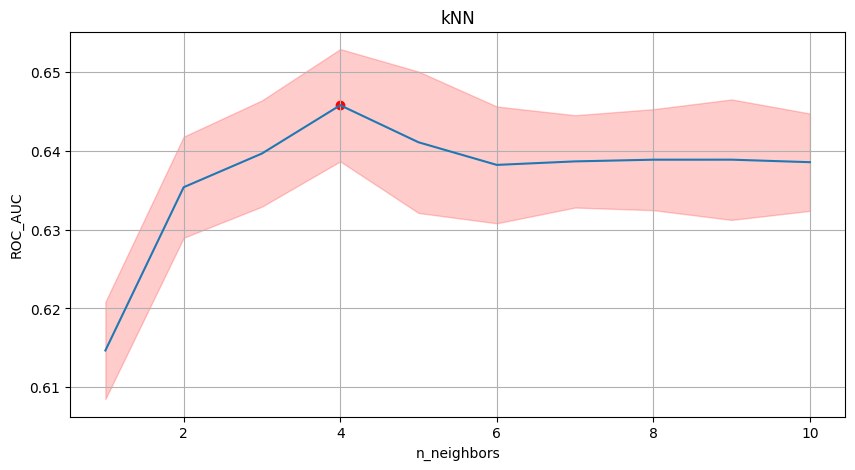

In [76]:
means2=np.array(gs2.cv_results_['mean_test_score'])
std2=np.array(gs2.cv_results_['std_test_score'])
param2=np.array(gs2.cv_results_['param_n_neighbors'],dtype=int)
plt.figure(figsize=(10,5))
plt.plot(param2, means2)
plt.xlabel("n_neighbors")
plt.ylabel("ROC_AUC")
plt.title("kNN")
plt.grid()
plt.fill_between(param2, means2-std2, means2+std2, alpha=0.2,color='red')
plt.scatter(4, 0.6457714736859134,color='red')
plt.show()

Качество модели растет при увеличении числа соседей с 1 до 4, а затем резко падает и выходит на плато. При оптимальном числе соседей разброс адексатный, что говорит об устойчивости модели (логично, т.к. не является алгоритмом машинного обучения)

#### **Задание 8 (0.5 балла)**

Также подберём число деревьев (`n_estimators`) в алгоритме RandomForest. Как известно, в общем случае Random Forest не переобучается с увеличением количества деревьев, так что при увеличении этого гиперпараметра его качество не будет становиться хуже. Поэтому подберите такое количество деревьев, при котором качество на кросс-валидации стабилизируется. Обратите внимание, что для проведения этого эксперимента не нужно с нуля обучать много случайных лесов с различными количествами деревьев. Обучите один случайный лес с максимальным интересным количеством деревьев, а затем рассмотрите подмножества разных размеров, состоящие из деревьев построенного леса (поле [`estimators_`](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)). В дальнейших экспериментах используйте это количество деревьев. Не забывайте про доверительный интервал.

In [83]:
model_RF=RandomForestClassifier(n_estimators=300,random_state=1,n_jobs=-1)
model_RF.fit(X,Y)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=1)

In [85]:
from tqdm import tqdm
from time import sleep

# с помощью ИИ
scores_mean=[]
scores_std=[]
for i in tqdm(range(1,301)):
    sleep(0.01)
    trees = RandomForestClassifier(
        n_estimators=i,
        random_state=1,
        n_jobs=-1)
    trees.estimators_ = model_RF.estimators_[:i]
    trees.classes_ = model_RF.classes_
    trees.n_features_in_ = model_RF.n_features_in_
    
    cv_scores = cross_val_score(trees, X, Y, cv=cr_val, scoring='roc_auc')
    scores_mean.append(cv_scores.mean())
    scores_std.append(cv_scores.std())

scores_mean = np.array(scores_mean)
scores_std  = np.array(scores_std)

100%|█████████████████████████████████████████| 300/300 [07:30<00:00,  1.50s/it]


In [89]:
m=scores_mean.max()
i_m=scores_mean.argmax() # максимальное, но не оптимальное количество деревьев
m,i_m

(0.8181572595639693, 248)

In [126]:
#с помощью ИИ
deltas = np.diff(scores_mean)
plateau_points = np.where(deltas < 0.0001)[0]
plateau_points[:10]

array([26, 27, 28, 38, 40, 42, 47, 50, 52, 53])

In [125]:
scores_mean[60] #оптимальный ROC-AUC

0.8151068636109707

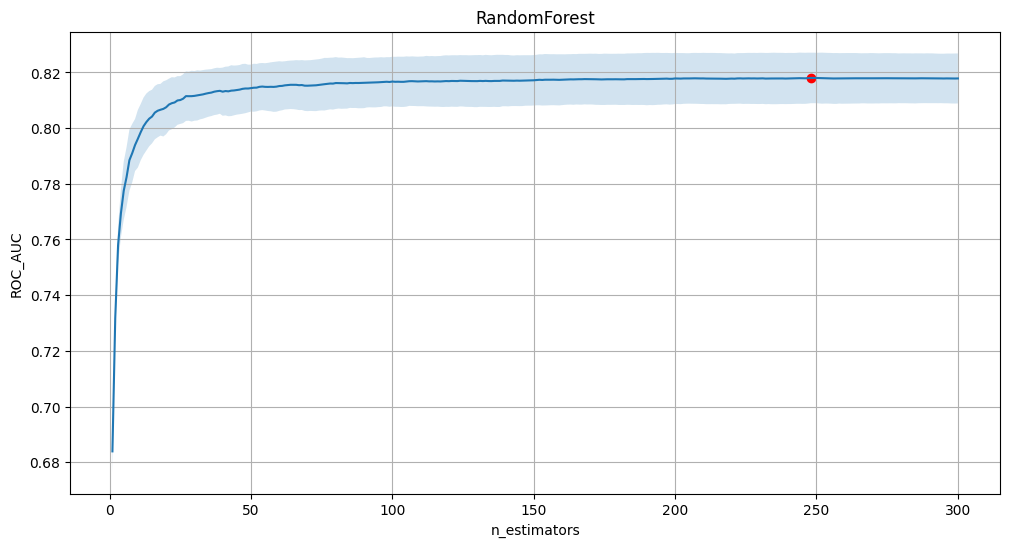

In [284]:
plt.figure(figsize=(12,6))
plt.plot(range(1,301), scores_mean, label='mean accuracy')
plt.fill_between(range(1,301), scores_mean - scores_std,
                 scores_mean + scores_std, alpha=0.2,color='red')
plt.title("RandomForest")
plt.xlabel("n_estimators")
plt.ylabel("ROC_AUC")
plt.scatter(i_m,m,color='red')
plt.grid()
plt.show()

Качество модели активно растет при увеличении количества деревьев с 0 до 150, а затем выходит на плато, достигая максимума при 248 деревьях. Дисперсия с ростом деревьев не растет, что подтвердает факт о независимости переобучения от числа деревьев. Оптимальным количеством деревьев стоит выбрать 60, т.к. уже с 50 добавление еще одного дерева дает минимальный прирост при значительной затрате вычислительных мощностей - модель оптимизируется.

#### **Задание 9 (0.5 балла)**

Подберём число деревьев (`n_estimators`) в алгоритме GradientBoosting. Мы знаем, что ошибка бустинга на тестовых данных, как правило, имеет U-образную форму, то есть сначала уменьшается, а при достижении некоторого числа деревьев начинает расти. Нарисуйте график ошибки в зависимости от числа деревьев. Подберите n_estimators, соответствующий минимуму ошибки. И не забывайте про доверительный интервал.

In [98]:
gs3=GridSearchCV(GradientBoostingClassifier(random_state=1),
                  param_grid={'n_estimators':[1,10,50,100,300,600,1000,2000]
                  },
                  cv=cr_val,
                  scoring='roc_auc')
gs3.fit(X,Y)
print(gs3.best_params_,gs3.best_score_)

{'n_estimators': 300} 0.8660992665476119


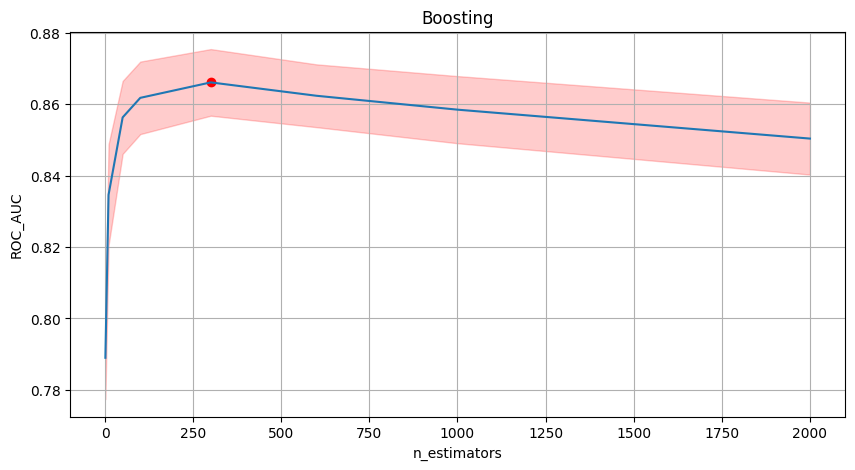

In [192]:
means3=np.array(gs3.cv_results_['mean_test_score'])
std3=np.array(gs3.cv_results_['std_test_score'])
param3=np.array(gs3.cv_results_['param_n_estimators'],dtype=int)
plt.figure(figsize=(10,5))
plt.plot(param3, means3)
plt.xlabel("n_estimators")
plt.ylabel("ROC_AUC")
plt.title("Boosting")
plt.grid()
plt.fill_between(param3, means3-std3, means3+std3, alpha=0.2,color='red')
plt.scatter(300, 0.8660992665476119,color='red')
plt.show()

Видим, что сначала метрика росла, но после достижения 300 деревьев ее качество начало ухудшаться, разброс тоже постепенно растет, что говорит об переобучении.

При обучении алгоритмов стоит обращать внимание не только на качество, но и каким образом они работают с данными. В этой задаче получилось так, что некоторые из используемых алгоритмов чувствительны к масштабу признаков. Чтобы убедиться, что это как-то могло повлиять на качество, давайте посмотрим на сами признаки.

#### **Задание 10 (0.5 балла)**

Постройте гистограммы для признаков `age`, `fnlwgt`, `capital-gain`. Глядя на получившиеся графики, в чем заключается особенность данных? На какие алгоритмы это может повлиять? Может ли масштабирование повлиять на работу этих алгоритмов?

<Axes: ylabel='Frequency'>

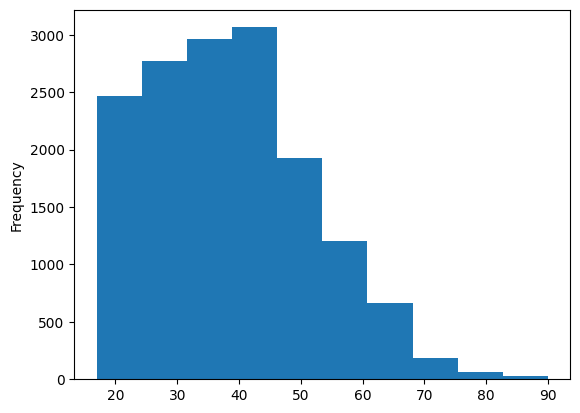

In [103]:
df['age'].plot(kind='hist',bins=10)

<Axes: ylabel='Frequency'>

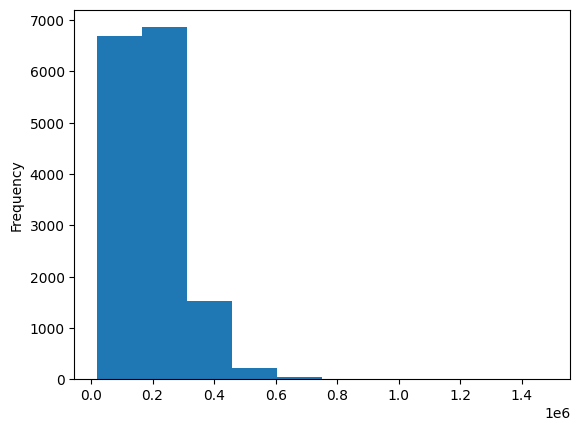

In [105]:
df['fnlwgt'].plot(kind='hist',bins=10)

<Axes: ylabel='Frequency'>

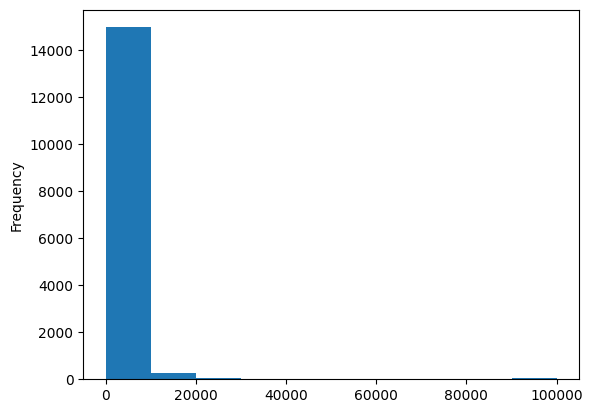

In [107]:
df['capital-gain'].plot(kind='hist',bins=10)

Все данные смещены влево, при этом находятся в разных масштабах. Такое распределение может результировать в придании алгоритмом значения наибольшим цифрам, а не наиболее важному критерию. Т.к. в среднем значения будут небольшими из-за левостороннего распределения, то разница в единицы может оказывать решающее влияние на вердикт, что не совсем логично.

Масштабирование признаков можно выполнить, например, одним из следующих способов способами:
 - $x_{new} = \dfrac{x - \mu}{\sigma}$, где $\mu, \sigma$ — среднее и стандартное отклонение значения признака по всей выборке (см. функцию [scale](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.scale.html));
 - $x_{new} = \dfrac{x - x_{min}}{x_{max} - x_{min}}$, где $[x_{min}, x_{max}]$ — минимальный интервал значений признака.

Похожие схемы масштабирования приведены в классах [StandardScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler) и [MinMaxScaler](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html#sklearn.preprocessing.MinMaxScaler).

#### **Задание 11 (0.5 балла)**

Масштабируйте все вещественные признаки одним из указанных способов и подберите оптимальные значения гиперпараметров аналогично пункту выше. Сделайте это для всех указанных выше алгоритмов.

In [111]:
scaler=StandardScaler()
scaler.fit(X)
X_S=scaler.transform(X)
X_S=pd.DataFrame(X_S, index=X.index,columns=X.columns)

**Decision Tree**

In [114]:
gs_S = GridSearchCV(DecisionTreeClassifier(random_state=1),
                  param_grid={ 'max_depth': list(range(1, 21))
                  },
                  cv=cr_val,
                  scoring='roc_auc')

gs_S.fit(X_S, Y)
print(gs_S.best_params_,gs_S.best_score_)

{'max_depth': 7} 0.8389624442687922


**SDG**

In [116]:
gs1_S=GridSearchCV(SGDClassifier(random_state=1),
                  param_grid={ 'loss': ['hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive']
                  },
                  cv=cr_val,
                  scoring='roc_auc')
gs1_S.fit(X_S, Y)
print(gs1_S.best_params_,
gs1_S.best_score_)

{'loss': 'log_loss'} 0.8199496681935518


**kNN**

In [118]:
gs2_S=GridSearchCV(KNeighborsClassifier(),
                  param_grid={ 'n_neighbors': range(1,11)
                  },
                  cv=cr_val,
                  scoring='roc_auc')
gs2_S.fit(X_S, Y)
print(gs2_S.best_params_,
gs2_S.best_score_)

{'n_neighbors': 10} 0.807809793918198


**Random Forest**

In [120]:
RF=RandomForestClassifier(n_estimators=300,random_state=1,n_jobs=-1)
RF.fit(X_S,Y)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=1)

In [124]:
scores_mean=[]
scores_std=[]
for i in tqdm(range(1,301)):
    sleep(0.01)
    trees = RandomForestClassifier(
        n_estimators=i,
        random_state=1,
        n_jobs=-1)
    trees.estimators_ = RF.estimators_[:i]
    trees.classes_ = RF.classes_
    trees.n_features_in_ = RF.n_features_in_
    
    cv_scores = cross_val_score(trees, X_S, Y, cv=cr_val, scoring='roc_auc')
    scores_mean.append(cv_scores.mean())
    scores_std.append(cv_scores.std())

scores_mean_S = np.array(scores_mean)
scores_std_S  = np.array(scores_std)

100%|█████████████████████████████████████████| 300/300 [07:15<00:00,  1.45s/it]


In [130]:
scores_mean_S.argmax() #раз максимум не сдвинулся плато оставим тем же

248

In [132]:
scores_mean_S.max()

0.8179637933880013

In [134]:
scores_mean_S[60]#оптимальный ROC-AUC

0.8151068636109707

**Boosting**

In [136]:
gs3_S=GridSearchCV(GradientBoostingClassifier(random_state=1),
                  param_grid={'n_estimators':[1,10,50,100,300,600,1000,2000]
                  },
                  cv=cr_val,
                  scoring='roc_auc')
gs3_S.fit(X_S,Y)
print(gs3_S.best_params_,gs3_S.best_score_)

{'n_estimators': 300} 0.8660996130157077


Для дерева решений и случайного леса значения гипперпараметра не изменилось с маштабированием. Для kNN, как и стоило ожидать, число соседей выросло с 4 до 10, т.к растояние стало зависеть не от масштаба переменной, а вычислялось универсально - ROC-AUC тоже вырос на 0.2. SGD получил преимущества от маштабирования, т.к его метрика качества тоже выросла на 0.2 в результате переоценки весов. Boosting показал наилучшие результаты из всех моделей в виду алгоритма под капотом, исправляющего ошибки.

#### **Задание 12 (0.5 балла)**

Теперь сделайте перебор нескольких гиперпараметров по сетке и найдите оптимальные комбинации (лучшее среднее значение качества) для каждого алгоритма в данном случае:
 - KNN — число соседей (`n_neighbors`) и метрика (`metric`);
 - DecisonTree — глубина дерева (`max_depth`) и критерий разбиения (`criterion`);
 - RandomForest — критерий разбиения в деревьях (`criterion`) и `max_features` (при фиксированном количестве деревьев, найденном ранее);
 - GradientBoosting — критерий разбиения в деревьях (`criterion`) и `max_features` (при фиксированном количестве деревьев, найденном ранее);
 - SGDClassifier — оптимизируемая функция (`loss`) и `penalty`.

Обратите внимание, что эта операция может быть ресурсо- и трудоемкой. Как оптимизировать подбор параметров по сетке сказано в разделе "Подбор гиперпараметров модели".

*Не будем оптимизировать, дабы не потерять наилучшую комбинацию*

**kNN**

In [140]:
start_time = time.time()
m1=GridSearchCV(KNeighborsClassifier(),
                  param_grid={ 'n_neighbors': range(1,11), 'metric': ['minkowski','cityblock','euclidean','manhattan']
                  },
                  cv=cr_val,
                  scoring='roc_auc')
end_time = time.time()
execution_time = end_time - start_time
m1.fit(X_S, Y)
print(m1.best_params_,
m1.best_score_, f'Время работы: {execution_time}')

{'metric': 'cityblock', 'n_neighbors': 10} 0.8083328299406976 Время работы: 0.00036716461181640625


**Decision Tree**

In [142]:
start_time = time.time()
m2 = GridSearchCV(DecisionTreeClassifier(random_state=1),
                  param_grid={ 'max_depth': list(range(1, 21)),'criterion':['gini', 'entropy', 'log_loss']
                  },
                  cv=cr_val,
                  scoring='roc_auc')
end_time = time.time()
execution_time = end_time - start_time
m2.fit(X_S, Y)
print(m2.best_params_,m2.best_score_,f'Время работы: {execution_time}')

{'criterion': 'gini', 'max_depth': 7} 0.8389624442687922 Время работы: 0.0002880096435546875


**Random Forest**

In [144]:
start_time = time.time()
m3=GridSearchCV(RandomForestClassifier(random_state=1,n_estimators=60),
                param_grid={'criterion':['gini', 'entropy', 'log_loss'],'max_features':['sqrt', 'log2', None]},
                cv=cr_val,
                scoring='roc_auc')
end_time = time.time()
execution_time = end_time - start_time
m3.fit(X_S, Y)
print(m3.best_params_,m3.best_score_,f'Время работы: {execution_time}')

{'criterion': 'entropy', 'max_features': None} 0.8159204726741143 Время работы: 0.0004596710205078125


**Boosting**

In [146]:
start_time = time.time()
m4=GridSearchCV(GradientBoostingClassifier(random_state=1,n_estimators=300),
                  param_grid={'criterion':['friedman_mse', 'squared_error'],'max_features':['sqrt', 'log2', None]
                  },
                  cv=cr_val,
                  scoring='roc_auc')
end_time = time.time()
execution_time = end_time - start_time
m4.fit(X_S,Y)
print(m4.best_params_,m4.best_score_,f'Время работы: {execution_time}')

{'criterion': 'friedman_mse', 'max_features': None} 0.8660996130157077 Время работы: 0.00041103363037109375


**SGD**

In [154]:
start_time = time.time()
m5=GridSearchCV(SGDClassifier(random_state=1),
                  param_grid={ 'loss': ['hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'],
                  'penalty':['l2', 'l1', 'elasticnet', None]},
                  cv=cr_val,
                  scoring='roc_auc')
end_time = time.time()
execution_time = end_time - start_time
m5.fit(X_S, Y)
print(m5.best_params_,
m5.best_score_,f'Время работы: {execution_time}')

{'loss': 'log_loss', 'penalty': 'elasticnet'} 0.820157530784073 Время работы: 0.000804901123046875


Как и ожидалось, Boosting имеет наилучшее качество с ROC-AUC=0.87, что ближе всего к 1 среди всех моделей. Однако, если говорить про соотношение метрика/время, то решающее дерево - лучшая модель, т.к. ROC-AUC отличается всего на 0.03, зато сокращено порядочное количество времени. Наиболее подходящие значения гипер параметров можно видеть на экране. Их подбор не сильно, если вообще  увеличил метрики качества для всех моделей по сравнению с прошлым заданием.

#### **Задание 13 (0.5 балла)**

Сравните алгоритмы с точки зрения времени обучения. Обучение какого из алгоритмов работает дольше всего и, как вы думаете, почему?

Дольше всего работает SGD, т.к. имеет наибольший набор параметров для пербора. На втором месте - решающий лес, т.к. обучение каждого из деревьев - довольно трудоъемкий процесс, хоть они и были сокращены оптимально. Быстрее всего сработало одно решающее дерево в силу своей простоты.

### **Добавление категориальных признаков в модели**

Пока мы не использовали нечисловые признаки, которые есть в датасете. Давайте посмотрим, правильно ли мы сделали и увеличится ли качество моделей после добавлениях этих признаков.

#### **Задание 14 (0.5 балла)**

Преобразуйте все категориальные признаки с помощью метода one-hot-encoding (например, это можно сделать с помощью функции [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html), [pandas.get_dummies](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html) или [DictVectorizer](http://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.DictVectorizer.html) из sklearn).

In [157]:
X1=pd.get_dummies(df.select_dtypes(exclude=['number']),df.select_dtypes(exclude=['number']).columns)

#### **Задание 15 (0.5 балла)**

Добавьте к масштабированным вещественным признакам закодированные категориальные и обучите алгоритмы с наилучшими гиперпараметрами из предыдущего пункта. Дало ли добавление новых признаков прирост качества? Измеряйте качество, как и раньше используя 5-Fold CV. Для этого удобно воспользоваться функцией [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).

In [159]:
df1=pd.concat([X_S, X1], axis=1)

In [475]:
pip install threadpoolctl==3.1.0

  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 2.2.0
    Uninstalling threadpoolctl-2.2.0:
      Successfully uninstalled threadpoolctl-2.2.0
Note: you may need to restart the kernel to use updated packages.


In [165]:
model1=KNeighborsClassifier(metric='cityblock', n_neighbors= 10)
c1=cross_val_score(model1,df1,Y,cv=cr_val,scoring='roc_auc_ovr')
print(c1.mean())

0.8735383539852982


In [167]:
model2=DecisionTreeClassifier(criterion='gini',max_depth= 7,random_state=1)
c2=cross_val_score(model2,df1,Y,cv=cr_val,scoring='roc_auc')
print(c2.mean())

0.8889740144250684


In [171]:
model3=SGDClassifier(loss='log_loss', penalty= 'elasticnet',random_state=1)
c3=cross_val_score(model3,df1,Y,cv=cr_val,scoring='roc_auc')
print(c3.mean())

0.9017093199081622


In [177]:
model4=RandomForestClassifier(n_estimators=60,criterion='entropy', max_features = None, random_state=1)
c4=cross_val_score(model4,df1,Y,cv=cr_val,scoring='roc_auc')
print(c4.mean())

0.8980465082008356


In [181]:
model5=GradientBoostingClassifier(n_estimators=300,criterion='friedman_mse', max_features = None, random_state=1)
c5=cross_val_score(model5,df1,Y,cv=cr_val,scoring='roc_auc')
print(c5.mean())

0.9241082667817089


Добавление категориальных признаков дало значительный прирост качества для всех моделей, порядка 0.1. Наибольший прирост наблюдается у SGD, чо говорит о функциональной значимости категориальных признаков для правильного распределения весов. Лучший результат показал Boosting, как и ожидалось

### **Использование продвинутых алгоритмов**

#### **Задание 16 (0.5 балла)**

Помимо использованных моделей выше, добавьте `catboost`, `xgboost`, `lightgbm`. Используйте гиперпараметры по умолчанию.

In [456]:
try:
    import catboost
    print("CatBoost уже установлен")
except ImportError:
    print("Устанавливаем CatBoost...")
    !pip install catboost
    import catboost
    print("CatBoost успешно установлен")
!pip install lightgbm

CatBoost уже установлен
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 3.2 MB/s eta 0:00:00a 0:00:01


In [459]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 4.7 MB/s eta 0:00:00a 0:00:01


In [184]:
import lightgbm
import xgboost

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [185]:
catboost = CatBoostClassifier(verbose=False,random_state=1)#дабы не печатал во время обучения
catboost.fit(df1, Y)
c6=cross_val_score(catboost,df1,Y,cv=cr_val,scoring='roc_auc')
print(c6.mean())

0.9252739105836005


In [188]:
xgb = XGBClassifier(verbosity=0,random_state=1)
xgb.fit(df1, Y)
c7=cross_val_score(xgb,df1,Y,cv=cr_val,scoring='roc_auc')
print(c7.mean())

0.921019283732053


In [190]:
lightgbm = LGBMClassifier(random_state=1,verbose=0)
lightgbm.fit(df1, Y)
c8=cross_val_score(lightgbm,df1,Y,cv=cr_val,scoring='roc_auc')
print(c8.mean())

0.9226128731150773


Лучше всего из коробки сработал кат буст, показав наиболее высокое значение рок-аук среди всех использованных моделей за сегодня. Если сравнивать xgb,gradientboosting и lightgbm, то бустинг с 3 гиперпараметрами сработал даже лучше чем данные модели, т.к. никак не специфицированны под данные. Однако быстреев всего сработал lightgbm, с результатом близким обычному бустингу, но гораздо меньшими затратами времени

### **Сравнение моделей**

После того как было построено много моделей, хотелось бы сравнить их между собой. Для этого можно построить "ящик с усами" (диаграмма размаха). Для этого можно воспользоваться библиотекой [matplotlib](https://matplotlib.org/3.1.0/api/_as_gen/matplotlib.pyplot.boxplot.html) или [seaborn](https://seaborn.pydata.org/generated/seaborn.boxplot.html).

#### **Задание 17 (0.5 балла)**

Постройте ящик с усами / boxplot для всех реализованных моделей в двух последних заданиях. Дополнительно сделайте скрипичный график / violinplot.

Для каждого типа классификатора выберите тот, который давал наилучшее качество на кросс-валидации (с учетом подобранных гиперпараметров) и постройте диаграмму размаха (все классификаторы должны быть изображены на одном графике).

Сделайте общие итоговые выводы о классификаторах с точки зрения их работы с признаками и сложности самой модели (какие гиперпараметры есть у модели, сильно ли изменение значения гиперпараметра влияет на качество модели).

In [193]:
metrics=[c1,c2,c3,c4,c5,c6,c7,c8]
metric = pd.DataFrame(metrics).T
metric.columns = ['kNN', 'DecisionTree', 'SGD', 'RandomForest',
                  'Boosting', 'catboost', 'xgb', 'lightgbm']

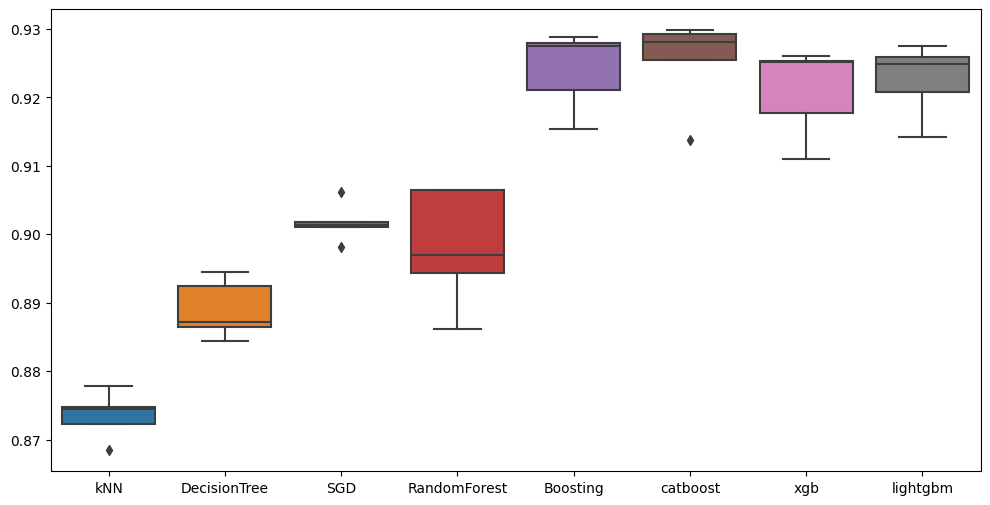

In [195]:
plt.figure(figsize=(12,6))
sns.boxplot(data=metric)
plt.show()

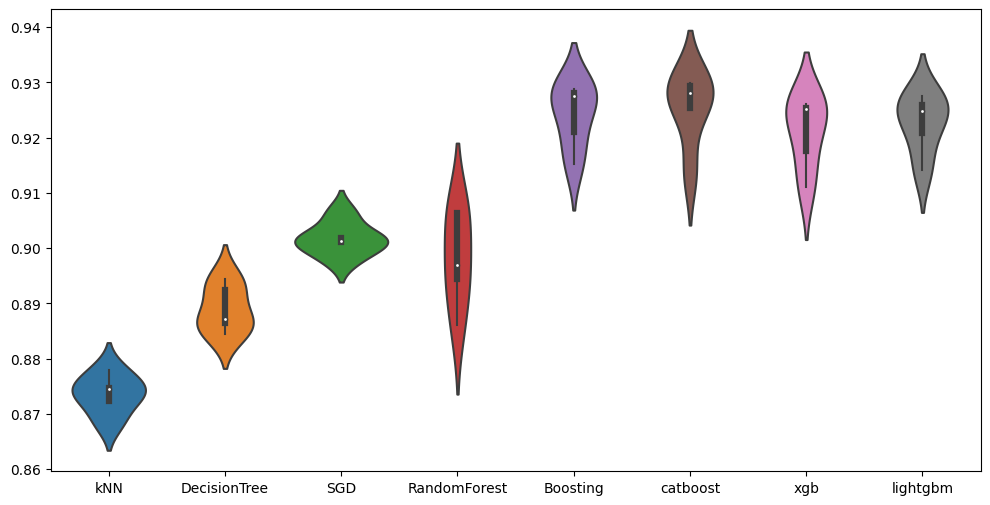

In [197]:
plt.figure(figsize=(12,6))
sns.violinplot(data=metric)
plt.show()

Общие выводы: настройки гиперпараметров и нормировка данных, несомненно, помогли улучшить метрики моделей, причем значительно. Добавление категориальных признаков также уменьшило bias классификаторов. Из графиков мы видим, что самая лучшая модель - catboost, т.к. она дает довольно низкую дисперсию при наибольшей точности. Модель с наименьшей точностью - kNN, модель с наибольшим разбросом - Random Forest. Модель с наименьшей дисперсией - SGD.

## **Часть 3 (1 балл)**

В этой части мы попробуем реализовать своё собственное дерево для задачи классификации на разных датасетах из sklearn.

#### **Задание 18 (1 балл)**

Допишите код ниже для дерева из исходников.

In [199]:
class SimpleDecisionTree:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.tree = {}
        self.feature_names = None

    def calculate_gini(self, labels):
        """Вычисляем коэффициент Джини для набора меток"""
        if len(labels) == 0:
            return 0

        # Подсчёт вероятностей каждого класса
        unique, counts = np.unique(labels, return_counts=True)
        probabilities = counts/len(labels)

        # Формула Джини: 1 - sum(p_i^2)
        gini = 1-np.sum(probabilities**2)
        return gini

    def find_best_split(self, X, y):
        """Находим лучший признак и значение для разделения"""
        best_gini = float('inf')
        best_feature = None
        best_value = None

        # Перебираем все признаки
        for feature in range(X.shape[1]):
            # Перебираем уникальные значения признака
            unique_values = np.unique(X[:, feature])
            for value in unique_values:
                # Разделяем данные
                left_mask = X[:, feature] <= value
                right_mask = ~left_mask

                left_y = y[left_mask]
                right_y = y[right_mask]

                # Пропускаем, если одна из сторон пустая
                if len(left_y) == 0 or len(right_y) == 0:
                    continue

                # Вычисляем взвешенный Джини
                total = len(y)
                left_weight = len(left_y)/total
                right_weight =len(right_y)/total

                weighted_gini =(left_weight * self.calculate_gini(left_y)+ right_weight * self.calculate_gini(right_y))

                # Обновляем лучший сплит
                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature
                    best_value = value

        return best_feature, best_value, best_gini

    def build_tree(self, X, y, depth=0):
        """Рекурсивно строит дерево"""
        # Базовые случаи рекурсии
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            # Возвращаем самый частый класс
            unique, counts = np.unique(y, return_counts=True)
            return {'prediction': unique[np.argmax(counts)]}

        # Находим лучший сплит
        feature, value, gini = self.find_best_split(X, y)

        # Если не нашли хороший сплит
        if feature is None:
            unique, counts = np.unique(y, return_counts=True)
            return {'prediction': unique[np.argmax(counts)]}

        # Разделяем данные
        left_mask = X[:, feature] <= value
        right_mask = ~left_mask

        # Рекурсивно строим поддеревья
        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        # Возвращаем узел дерева
        return {
            'feature': feature,
            'value': value,
            'left': left_subtree,
            'right': right_subtree
        }

    def fit(self, X, y):
        """Обучаем дерево на данных"""
        # Сохраняем названия признаков, если это DataFrame
        if hasattr(X, 'columns'):
            self.feature_names = X.columns.tolist()

        # Преобразуем в numpy массивы
        X_array = X.values if hasattr(X, 'values') else X
        y_array = y.values if hasattr(y, 'values') else y

        self.tree = self.build_tree(X_array, y_array)

    def predict_single(self, x, node):
        """Предсказывает для одного примера"""
        if 'prediction' in node:
            return node['prediction']

        # Получаем значение признака
        if hasattr(x, 'iloc'):  # pandas Series
            feature_val = x.iloc[node['feature']]
        elif hasattr(x, 'shape'):  # numpy array
            feature_val = x[node['feature']]
        else:  # список или другой iterable
            feature_val = x[node['feature']]

        if feature_val <= node['value']:
            return self.predict_single(x, node['left'])
        else:
            return self.predict_single(x, node['right'])

    def predict(self, X):
        """Предсказываем для всех примеров"""
        predictions = []
        X_array = X.values if hasattr(X, 'values') else X

        for i in range(len(X_array)):
            x_row = X_array[i]
            pred = self.predict_single(x_row, self.tree)
            predictions.append(pred)
        return np.array(predictions)

    def print_tree(self, node=None, indent=0):
        """Печатаем дерево"""
        if node is None:
            node = self.tree

        if 'prediction' in node:
            print(" " * indent + f"Предсказание: {node['prediction']}")
        else:
            feature_name = f"признак_{node['feature']}"
            if self.feature_names:
                feature_name = self.feature_names[node['feature']]
            print(" " * indent + f"Если {feature_name} <= {node['value']:.3f}:")
            print(" " * indent + "  Да ->")
            self.print_tree(node['left'], indent + 4)
            print(" " * indent + "  Нет ->")
            self.print_tree(node['right'], indent + 4)

Протестируем наше дерево. И сравним это со стандартным деревом из sklearn.

In [201]:
def test_on_dataset(dataset, dataset_name, max_depth=3):
    X, y = dataset.data, dataset.target

    feature_names = dataset.feature_names
    X_df = pd.DataFrame(X, columns=feature_names)
    y_series = pd.Series(y, name='target')

    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y_series, test_size=0.3, random_state=42, stratify=y
    )

    # Наше дерево
    our_tree = SimpleDecisionTree(max_depth=max_depth)
    our_tree.fit(X_train, y_train)
    our_predictions = our_tree.predict(X_test)
    our_accuracy = accuracy_score(y_test, our_predictions)

    # Сравниваем с sklearn DecisionTree
    sklearn_tree = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    sklearn_tree.fit(X_train, y_train)
    sklearn_predictions = sklearn_tree.predict(X_test)
    sklearn_accuracy = accuracy_score(y_test, sklearn_predictions)

    print(f"\n=== {dataset_name} ===")
    print(f"Наше дерево:      {our_accuracy:.4f}")
    print(f"Sklearn дерево:   {sklearn_accuracy:.4f}")
    print(f"Размерность: {X.shape[1]} признаков, {len(np.unique(y))} классов")

    return our_accuracy, sklearn_accuracy

# Тестируем на разных датасетах
datasets = [
    (load_iris(), "Iris"),
    (load_breast_cancer(), "Breast Cancer"),
    (load_wine(), "Wine")
]

results = {}
for dataset, name in datasets:
    our_acc, sklearn_acc = test_on_dataset(dataset, name, max_depth=3)
    results[name] = {'our_tree': our_acc, 'sklearn_tree': sklearn_acc}


=== Iris ===
Наше дерево:      0.9333
Sklearn дерево:   0.9778
Размерность: 4 признаков, 3 классов

=== Breast Cancer ===
Наше дерево:      0.9240
Sklearn дерево:   0.9240
Размерность: 30 признаков, 2 классов

=== Wine ===
Наше дерево:      0.9630
Sklearn дерево:   0.9630
Размерность: 13 признаков, 3 классов


Дерево из библиотеки сработало лучше на одном тесте из 3, на остальных же тестах они идентичны. Такие результаты можно объяснить более гибкими параметрами в sklearn, где каждый из них может варироваться в зависимости от выходных данных тогда, как наше дерево способно работать только с параметром максимальной грубины.

Посмотрим на структуру нашего дерева и визуализируем результаты.

In [149]:
# Загружаем данные
iris = load_iris()
X, y = iris.data, iris.target

# Берем только 2 класса и 2 признака для простоты визуализации
mask = y < 2  # только setosa и versicolor
X_simple = X[mask, :2]  # только sepal_length и sepal_width
y_simple = y[mask]

df_iris = pd.DataFrame(X_simple, columns=['sepal_length', 'sepal_width'])
df_iris['target'] = y_simple

print("Упрощенный датасет Iris:")
print(df_iris.head())
print(f"\nКлассы: {np.unique(y_simple)}")
print(f"Размер: {df_iris.shape}")

# Обучаем наше дерево
simple_tree = SimpleDecisionTree(max_depth=2)
simple_tree.fit(df_iris[['sepal_length', 'sepal_width']], df_iris['target'])

# Предсказания
predictions = simple_tree.predict(df_iris[['sepal_length', 'sepal_width']])
accuracy = accuracy_score(df_iris['target'], predictions)

print(f"\nТочность на обучающих данных: {accuracy:.3f}")
print("\nСтруктура дерева:")
simple_tree.print_tree()

Упрощенный датасет Iris:
   sepal_length  sepal_width  target
0           5.1          3.5       0
1           4.9          3.0       0
2           4.7          3.2       0
3           4.6          3.1       0
4           5.0          3.6       0

Классы: [0 1]
Размер: (100, 3)

Точность на обучающих данных: 0.980

Структура дерева:
Если sepal_length <= 5.400:
  Да ->
    Если sepal_width <= 2.700:
      Да ->
        Предсказание: 1
      Нет ->
        Предсказание: 0
  Нет ->
    Если sepal_width <= 3.400:
      Да ->
        Предсказание: 1
      Нет ->
        Предсказание: 0


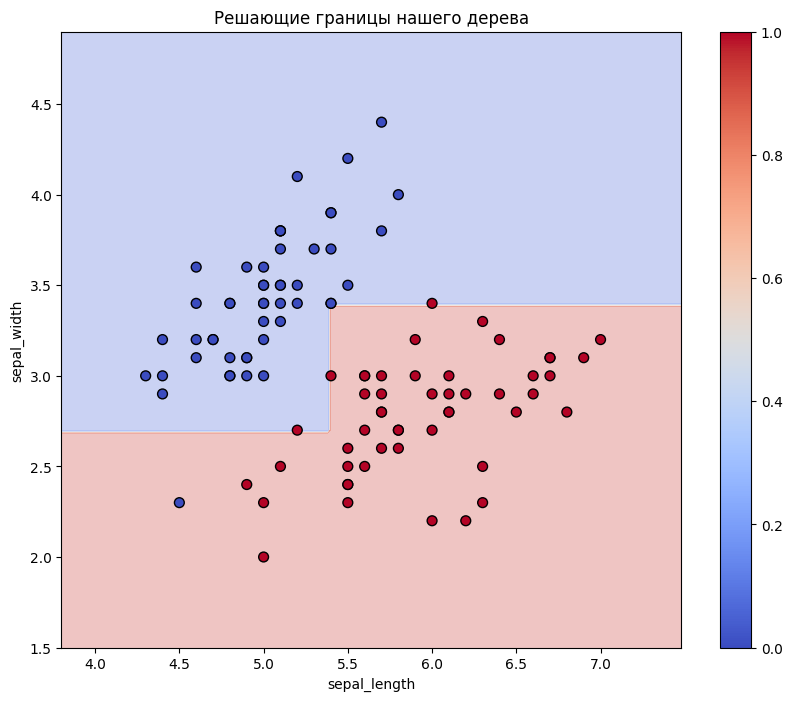

In [151]:
def plot_decision_boundary(tree, X, y, feature_names):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm',
                         edgecolors='black', s=50)
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('Решающие границы нашего дерева')
    plt.colorbar(scatter)
    plt.show()

plot_decision_boundary(simple_tree,
                      df_iris[['sepal_length', 'sepal_width']].values,
                      df_iris['target'].values,
                      ['sepal_length', 'sepal_width'])

## **Мем (0 баллов)**

**Ты молодец и умница, держи картинку :)**

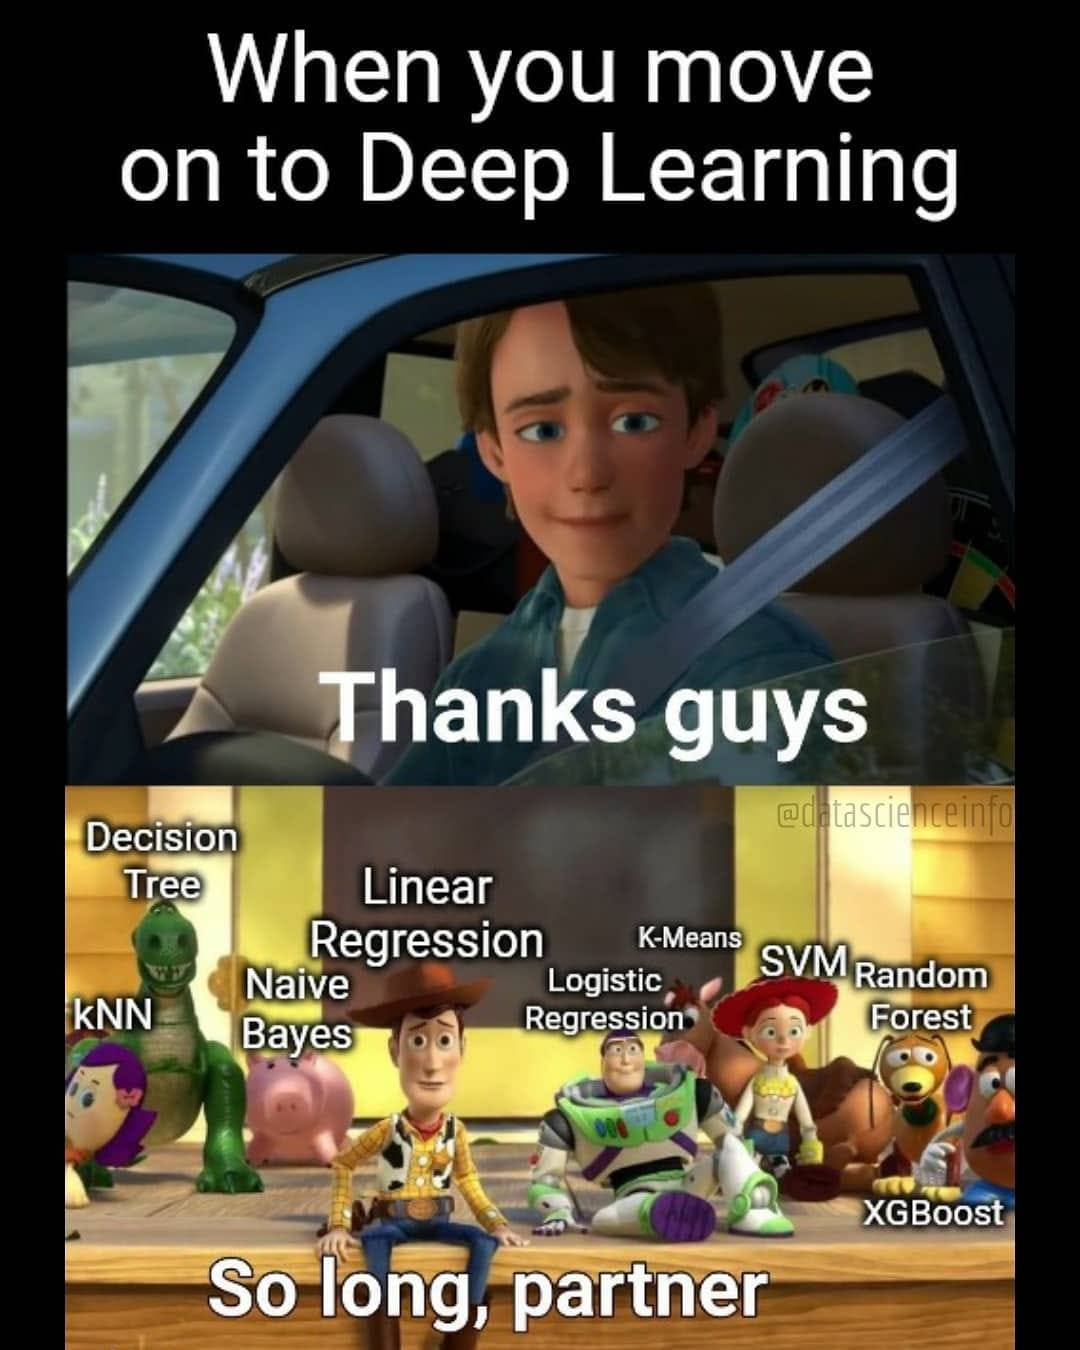